<h4 style="
  background: linear-gradient(135deg, #326572, #2a7383);
  font-family: 'Poppins', sans-serif;
  display: inline-block;
  padding: 14px 240px;
  margin: 25px auto;
  border-radius: 14px;
  color: #ffff;
  font-size: 2rem;
  font-weight: 400;
  letter-spacing: 1.5px;
  text-align: center;
  box-shadow: 0 6px 18px rgba(0,0,0,0.35);
  text-transform: uppercase;
  transition: all 0.3s ease;
">
  TaTa Motors 🚗
</h4>


<h2 style="
  font-family: 'Poppins', sans-serif;
  text-align: center;
  font-size: 1.05rem;
  color: white;
  margin: 12px auto;
  padding: 12px 255px;
  display: inline-block;
  border-radius: 134px;
  background: Teal;
  border-left: 5px solid #ffe066;
  border-right: 5px solid #ffe066;
  font-weight: 300;
  box-shadow: 0 6px 25px rgba(0,0,0,0.35);
">
                       Kaggle Dataset - Tata Motors stock 2006-2024
</h2>


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings 
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plta
import plotly.io as pio
# Set default Plotly theme
pio.templates.default = "plotly_white"

# Seaborn style
sns.set_style("whitegrid")

# Matplotlib defaults
# plt.rcParams.update({
#     "figure.facecolor": "white",
#     "axes.facecolor": "#f9f9f9",
#     "axes.edgecolor": "#2c3e50",
#     "grid.color": "#dfe6e9",
#     "grid.alpha": 0.7
# })

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [539]:
tm= pd.read_csv("/kaggle/input/datasets/raunakpandey030/tata-motors-limited-stock-prices-2006-2024/TATAMOTORS.NS.csv") 
print("TATA MOTORS Limited")
tm.head(3)

TATA MOTORS Limited


,Date,Open,High,Low,Close,Adj Close,Volume
0,2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.0
1,2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.0
2,2006-12-05,170.167969,170.867416,167.293518,169.209824,148.187225,6699838.0


# **Performing EDA**

In [540]:
print("Total Columns & Rows",tm.shape)

Total Columns & Rows (4233, 7)


In [541]:
tm.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

In [542]:
tm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4233 entries, 0 to 4232
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4233 non-null   object 
 1   Open       4226 non-null   float64
 2   High       4226 non-null   float64
 3   Low        4226 non-null   float64
 4   Close      4226 non-null   float64
 5   Adj Close  4226 non-null   float64
 6   Volume     4226 non-null   float64
dtypes: float64(6), object(1)
memory usage: 231.6+ KB


In [543]:
print("There is",tm.duplicated().sum(),"Duplicates.")

There is 0 Duplicates.


In [544]:
tm.isna().sum()

Date         0
Open         7
High         7
Low          7
Close        7
Adj Close    7
Volume       7
dtype: int64

**Here we see there is not a huge Null columns,So we can delete it!**

In [545]:
tm.isna().any()

Date         False
Open          True
High          True
Low           True
Close         True
Adj Close     True
Volume        True
dtype: bool

In [546]:
tm.describe().round(2) \
  .style.background_gradient(cmap="Dark2") \
  .format("{:.2f}")

,Open,High,Low,Close,Adj Close,Volume
count,4226.00,4226.00,4226.00,4226.00,4226.00,4226.00
mean,294.11,298.33,289.34,293.66,289.34,18628980.35
std,158.76,160.11,157.13,158.54,160.79,24454225.77
min,24.95,26.04,24.70,24.97,22.98,0.00
25%,155.34,158.10,152.57,155.34,145.96,6562862.75
50%,278.50,282.42,272.55,278.29,274.21,10693392.50
75%,423.86,428.41,418.80,423.14,421.59,19639270.50
max,823.85,827.00,819.50,823.55,823.55,390577839.00


In [547]:
tm.head(6).style.hide(axis="index").background_gradient(cmap="Set1")

Date,Open,High,Low,Close,Adj Close,Volume
2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.000000
2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.000000
2006-12-05,170.167969,170.867416,167.293518,169.209824,148.187225,6699838.000000
2006-12-06,167.121048,170.167969,165.568832,168.912796,147.927109,4822862.000000
2006-12-07,168.634933,171.701019,167.322250,171.068634,149.815109,3963218.000000
2006-12-08,170.551239,171.317749,165.425110,166.105408,145.468521,5872840.000000


***QUESTIONS***<br>
* Display the first 10 rows of the dataset.<br>
* Find the total number of trading days in the dataset.<br>
* Find the maximum, minimum, and average closing price.<br>
* Find the date on which the stock had its highest closing price.<br>
* Find the date on which the stock had its lowest closing price.<br>
* Calculate the daily price range (High - Low) for each day.<br>
* Find the mean, median, and standard deviation of the closing price.<br>
* Identify the days when the closing price was above the 50-day moving average.<br>
* Count the number of days when the stock closed higher than it opened.<br>
* Find the total volume traded per month.

In [548]:
# Display the first 10 rows of the dataset.
tm.head(10).style.background_gradient(cmap="plasma")

,Date,Open,High,Low,Close,Adj Close,Volume
0,2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.000000
1,2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.000000
2,2006-12-05,170.167969,170.867416,167.293518,169.209824,148.187225,6699838.000000
3,2006-12-06,167.121048,170.167969,165.568832,168.912796,147.927109,4822862.000000
4,2006-12-07,168.634933,171.701019,167.322250,171.068634,149.815109,3963218.000000
5,2006-12-08,170.551239,171.317749,165.425110,166.105408,145.468521,5872840.000000
6,2006-12-11,166.680298,166.680298,156.178940,160.864304,140.878540,6394422.000000
7,2006-12-12,160.778076,163.077637,144.681107,157.184998,137.656342,11916839.000000
8,2006-12-13,159.360001,163.844162,153.620667,161.180496,141.155457,6957223.000000
9,2006-12-14,161.448776,164.610687,160.222351,162.588974,142.388962,4875056.000000


In [549]:
# Find the total number of trading days in the dataset.
print("Total Trading days -",tm['Date'].nunique())


Total Trading days - 4233


In [550]:
# Find the maximum, minimum, and average closing price.
max_close = tm['Close'].max()
min_close = tm['Close'].min()
avg_close = tm['Close'].mean()

In [551]:
summary = {
    "Maximum Closing Price": round(max_close, 2),
    "Minimum Closing Price": round(min_close, 2),
    "Average Closing Price": round(avg_close, 2)
}

pd.DataFrame(summary, index=["Tata Motors"]).style.background_gradient(cmap="viridis").format("{:.2f}")

,Maximum Closing Price,Minimum Closing Price,Average Closing Price
Tata Motors,823.55,24.97,293.66


In [552]:
# Find the date on which the stock had its highest closing price.
tm["Date"] = pd.to_datetime(tm["Date"], errors="coerce")
# Create a new Year column
tm["Year"] = tm["Date"].dt.year

In [553]:
tm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4233 entries, 0 to 4232
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4233 non-null   datetime64[ns]
 1   Open       4226 non-null   float64       
 2   High       4226 non-null   float64       
 3   Low        4226 non-null   float64       
 4   Close      4226 non-null   float64       
 5   Adj Close  4226 non-null   float64       
 6   Volume     4226 non-null   float64       
 7   Year       4233 non-null   int32         
dtypes: datetime64[ns](1), float64(6), int32(1)
memory usage: 248.2 KB


In [554]:
tm.sample()

,Date,Open,High,Low,Close,Adj Close,Volume,Year
1450,2012-10-11,265.848511,271.982727,262.385651,270.894379,266.976959,7936504.0,2012


In [555]:
# Find the row with highest closing price
max_close_date = tm.loc[tm["Close"].idxmax(), ["Date", "Close"]]

print("Highest Closing Price Date:", max_close_date["Date"])
print("Closing Price:", round(max_close_date["Close"], 2)) 

Highest Closing Price Date: 2024-01-19 00:00:00
Closing Price: 823.55


In [556]:
# Find the date on which the stock had its lowest closing price.
min_close_date = tm.loc[tm["Close"].idxmin(), ["Date", "Close"]]

print("Highest Closing Price Date:", min_close_date["Date"])
print("Closing Price:", round(min_close_date["Close"], 2)) 

Highest Closing Price Date: 2008-11-20 00:00:00
Closing Price: 24.97


In [557]:
# Calculate the daily price range (High - Low) for each day.
tm.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume,Year
0,2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.0,2006
1,2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.0,2006


In [558]:
tm[["High", "Low"]] \
  .sort_values(by="High", ascending=False) \
  .head(10) \
  .style.background_gradient(cmap="Blues") \
  .format("{:.2f}")

,High,Low
4229,827.00,812.45
4232,826.00,819.50
4231,822.95,797.00
4228,820.40,810.30
4227,818.55,809.15
4226,817.50,808.45
4230,813.70,804.00
4225,811.00,792.65
4224,809.20,793.15
4222,805.90,787.10


In [559]:
# Find the median, and standard deviation of the closing price.
tm.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume,Year
0,2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.0,2006
1,2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.0,2006
2,2006-12-05,170.167969,170.867416,167.293518,169.209824,148.187225,6699838.0,2006


In [560]:
Close_mean =   tm["Close"].mean()
Close_median = tm["Close"].median()
Close_std = tm["Close"].std()

In [561]:
summary = {
    "Mean Closing Price": round(Close_mean, 2),
    "Median Closing Price": round(Close_median, 2),
    "Std Closing Price": round(Close_std, 2)
}

pd.DataFrame(summary, index=["Tata Motors"]).style.background_gradient(cmap="coolwarm").format("{:.2f}")

,Mean Closing Price,Median Closing Price,Std Closing Price
Tata Motors,293.66,278.29,158.54


In [562]:
# Identify the days when the closing price was above the 50-day moving average.
tm[tm["Close"]>293.66].head(2)

,Date,Open,High,Low,Close,Adj Close,Volume,Year
1326,2012-04-16,286.675110,298.696198,283.805908,297.508911,288.014862,12367613.0,2012
1327,2012-04-17,300.773895,301.713806,293.501892,298.152008,288.637390,14091462.0,2012


In [563]:
# Calculate 50-day moving average of Close
tm["50DMA"] = tm["Close"].rolling(window=50).mean()

# Filter days where Close > 50DMA
above_dma = tm[tm["Close"] > tm["50DMA"]]

# Display first 10 such days
above_dma[["Date", "Close", "50DMA","Year"]].sort_values(by="Close",ascending=False).head(10) \
    .style.background_gradient(cmap="coolwarm") \
    .format({"Close":"{:.2f}", "50DMA":"{:.2f}"})


,Date,Close,50DMA,Year
4232,2024-01-19 00:00:00,823.55,733.39,2024
4231,2024-01-18 00:00:00,819.05,729.82,2024
4229,2024-01-16 00:00:00,818.85,723.19,2024
4227,2024-01-12 00:00:00,816.45,715.85,2024
4226,2024-01-11 00:00:00,815.65,712.10,2024
4228,2024-01-15 00:00:00,812.45,719.55,2024
4225,2024-01-10 00:00:00,808.45,708.35,2024
4230,2024-01-17 00:00:00,805.55,726.36,2024
4224,2024-01-09 00:00:00,799.80,705.00,2024
4221,2024-01-04 00:00:00,795.75,695.64,2024


In [564]:
# Count the number of days when the stock closed higher than it opened.
tm[tm["Open"] > tm["Close"]].sort_values(by="Close",ascending=False).head(10) \
  .drop(columns=["50DMA",'Adj Close', 'Volume','High', 'Low'], errors="ignore") \
  .style.background_gradient(cmap="coolwarm")

,Date,Open,Close,Year
4232,2024-01-19 00:00:00,823.849976,823.549988,2024
4227,2024-01-12 00:00:00,818.150024,816.450012,2024
4228,2024-01-15 00:00:00,820.000000,812.450012,2024
4230,2024-01-17 00:00:00,811.000000,805.549988,2024
4224,2024-01-09 00:00:00,799.950012,799.799988,2024
4221,2024-01-04 00:00:00,798.000000,795.750000,2024
4222,2024-01-05 00:00:00,799.000000,790.950012,2024
4223,2024-01-08 00:00:00,798.400024,789.099976,2024
4219,2024-01-02 00:00:00,800.500000,784.400024,2024
4220,2024-01-03 00:00:00,786.049988,781.450012,2024


In [565]:
# Find the total volume traded per month.
tm["Month"] = tm["Date"].dt.month

In [566]:
tm.head(2)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,50DMA,Month
0,2006-12-01,173.042435,173.042435,155.268692,161.515854,141.449173,10001085.0,2006,NaN,12
1,2006-12-04,162.023666,170.512909,162.023666,169.085266,148.078171,18491096.0,2006,NaN,12


In [567]:
tm.groupby(["Date","Month"])["Volume"].sum() \
  .sort_values(ascending=False) \
  .head(11) \
  .to_frame(name="Total Volume") \
  .style.background_gradient(cmap="coolwarm") \
  .format("{:.0f}")


,,Total Volume
Date,Month,
2021-01-12 00:00:00,1,390577839
2021-01-22 00:00:00,1,316008609
2021-01-21 00:00:00,1,283614463
2021-02-02 00:00:00,2,251965965
2021-01-15 00:00:00,1,250038029
2021-02-03 00:00:00,2,224190114
2020-06-16 00:00:00,6,215476711
2021-01-20 00:00:00,1,205145151
2021-10-13 00:00:00,10,197949387


# ***Graphs***

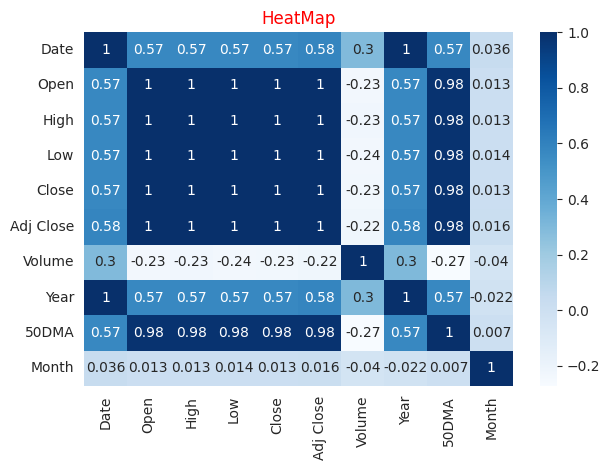

In [568]:
sns.heatmap(tm.corr(),annot=True,cmap="Blues")
plt.title("HeatMap",color="Red")
plt.tight_layout()
plt.show()

In [569]:
tm.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year',
       '50DMA', 'Month'],
      dtype='object')

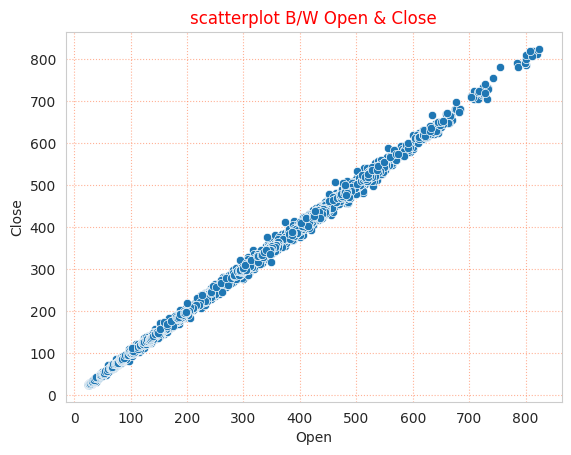

In [570]:
sns.scatterplot(data=df, x="Open", y="Close")
plt.title("scatterplot B/W Open & Close",color="Red")
plt.grid(linestyle=":",alpha=0.6,color="coral")
plt.show()


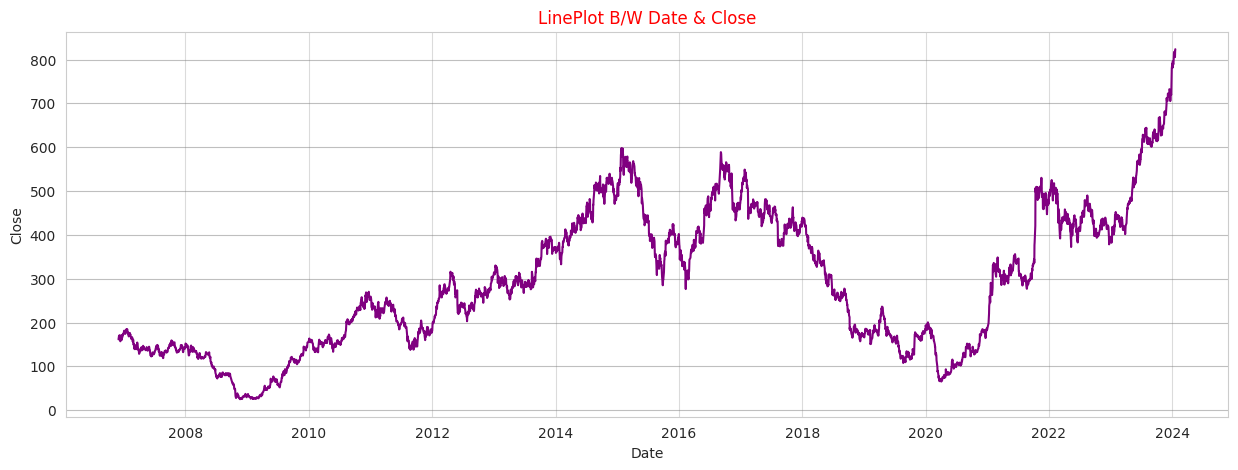

In [571]:
plt.figure(figsize=(15,5))
sns.lineplot(data=tm, x="Date", y="Close", color="purple")
plt.title("LinePlot B/W Date & Close", color="red")
plt.grid(axis="y", alpha=0.5, color="grey")
plt.show()


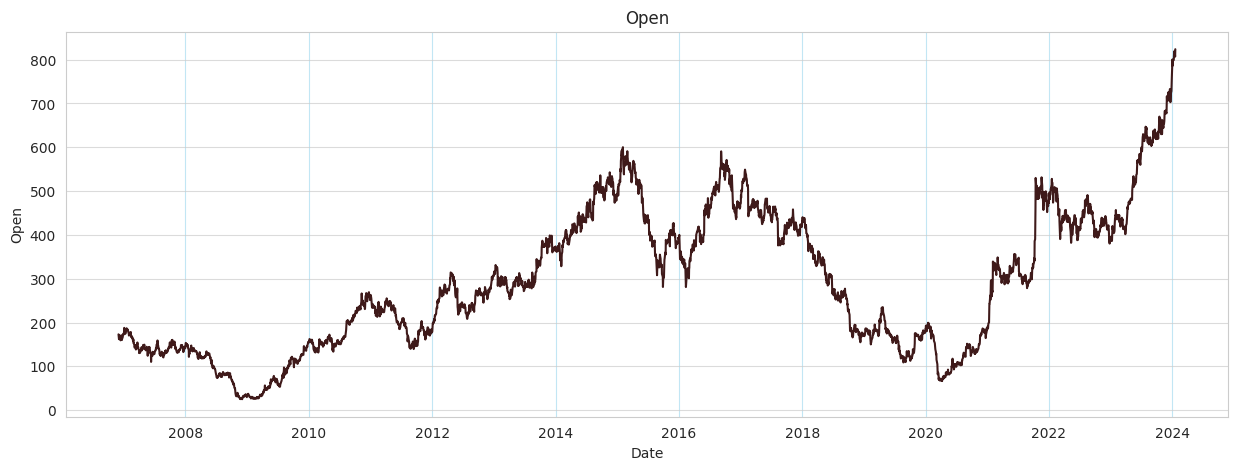

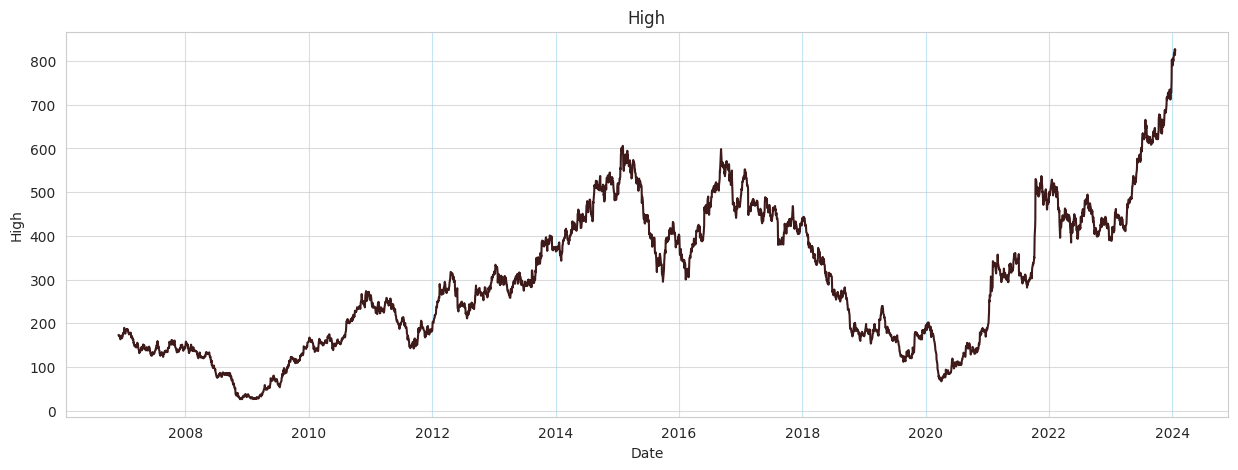

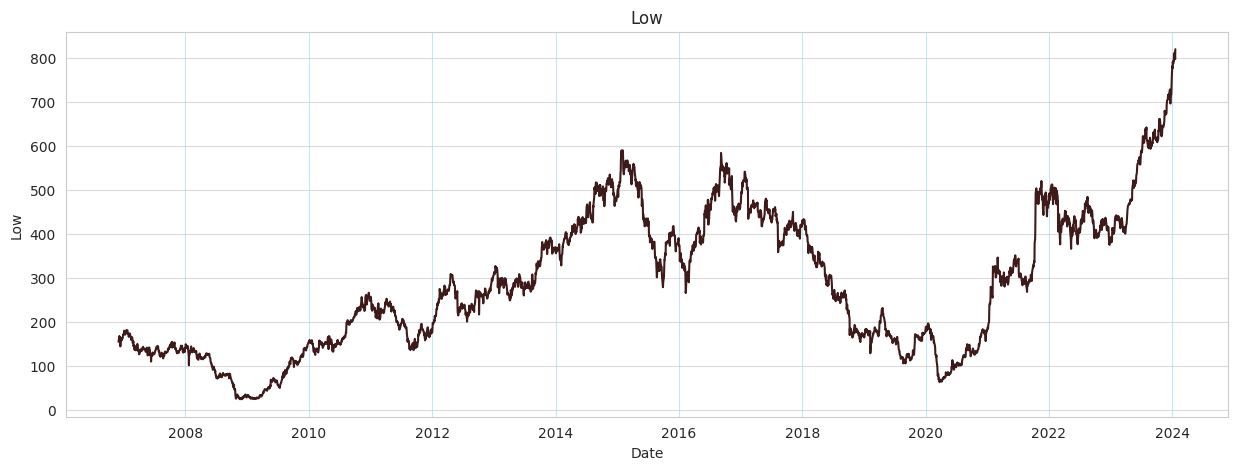

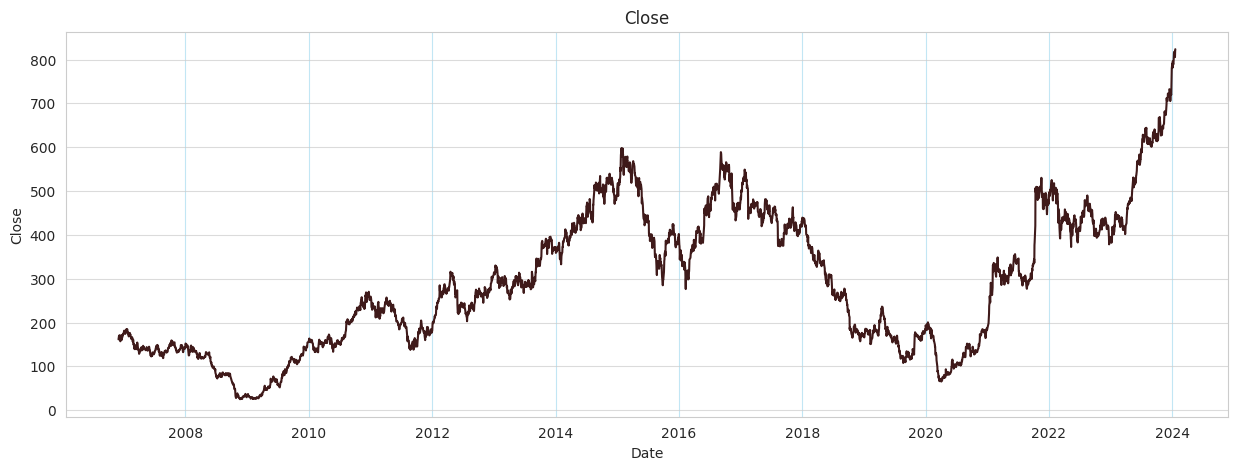

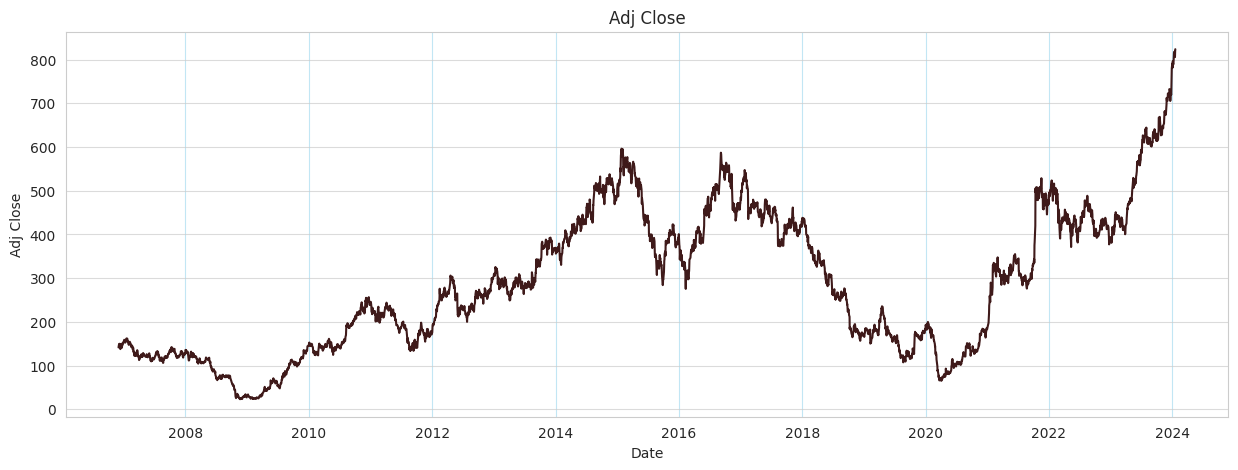

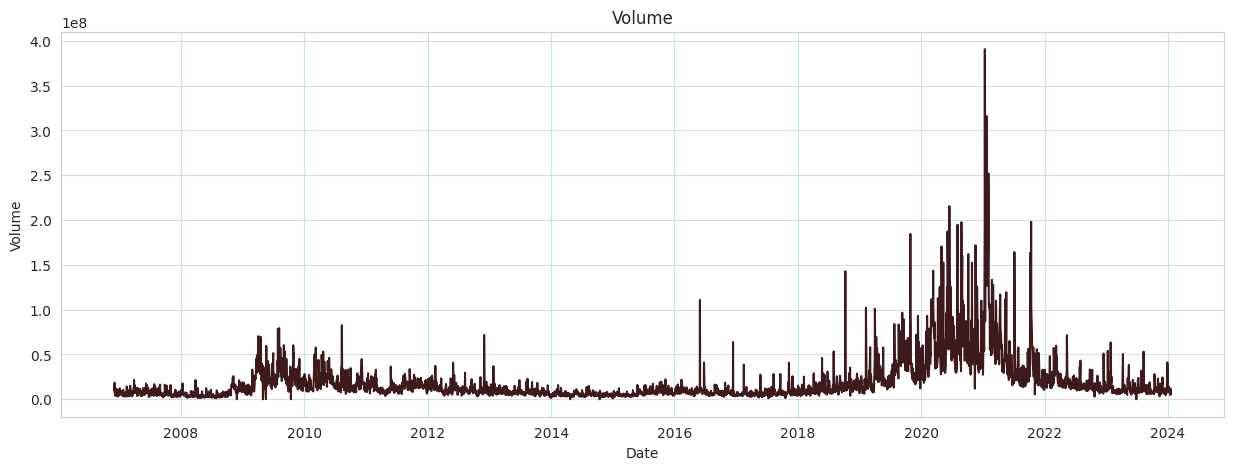

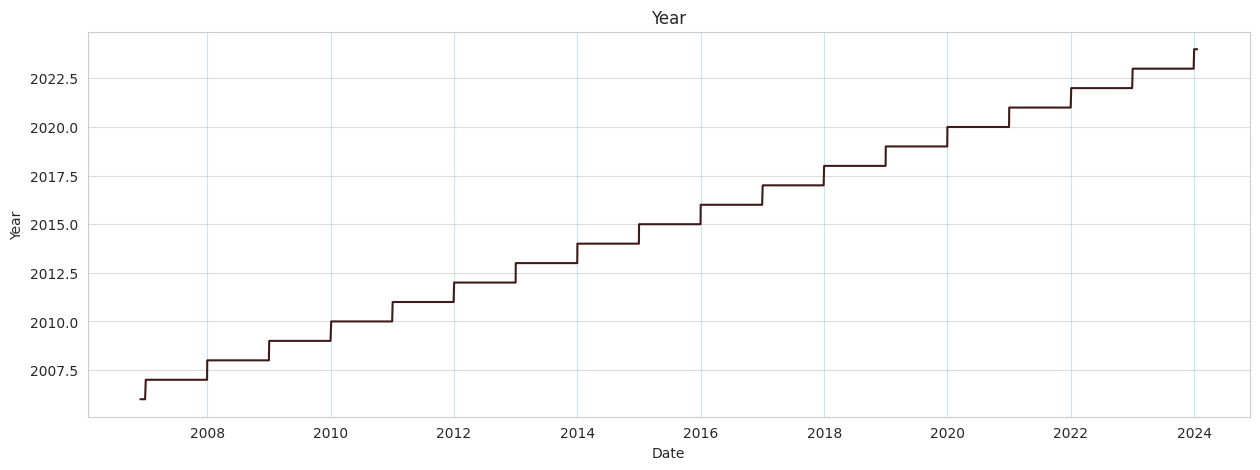

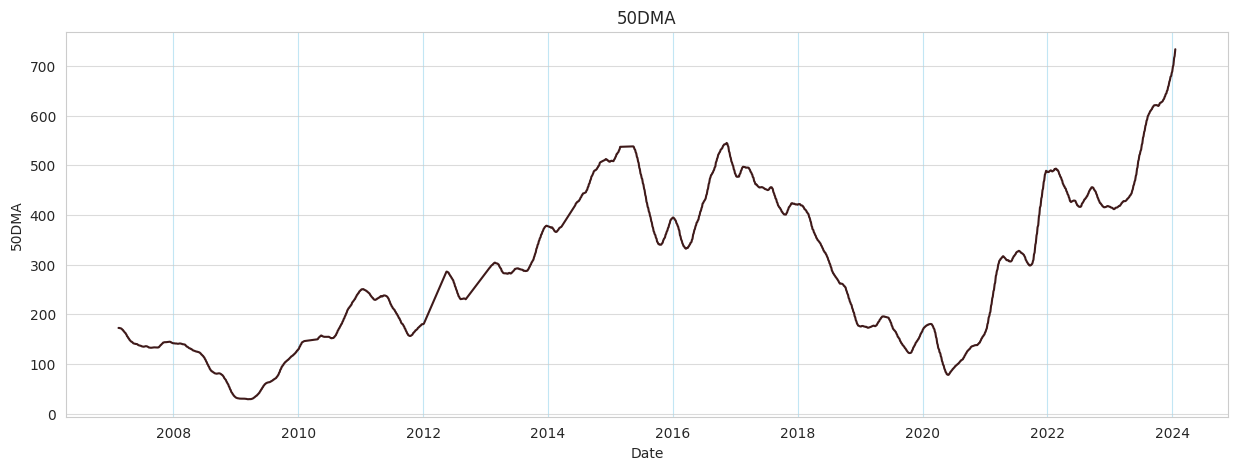

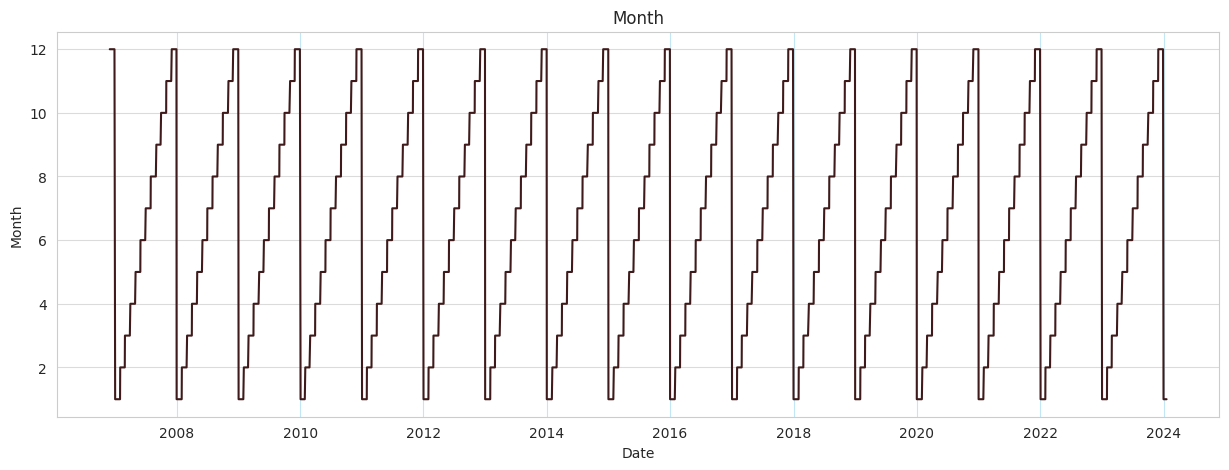

In [572]:
# Loop through all numeric columns except Date
for col in tm.drop(columns=["Date"]).columns:
    plt.figure(figsize=(15,5))
    sns.lineplot(data=tm, x="Date", y=col,color="#3f1a1a")
    plt.grid(axis="x", alpha=0.5, color="skyblue")
    plt.title(col)
    plt.show()


<H2 style="color : Yellow; text-align:Center; font-family: time ">Vicky Raj<br>ThankYou for opening this!</H2>